##### Libraries import

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path


##### Load and Merge predictions parquet files

In [ ]:
base = Path(r"C:\Users\chris\OneDrive - Danmarks Tekniske Universitet\Documents\DTU\Thesis\Green Power and KONSTANT\MSc_thesis_github_repo\MSc-Thesis")
rf_preds_path = base / "data" / "rf_predictions" /"rf_merged_predictions.parquet"
xgb_preds_path = base / "data" / "xgb_predictions" /"xgb_merged_predictions.parquet"

lf_rf = (pl.scan_parquet(rf_preds_path)
.rename({"EV_probability_mean": "rf_EV_probability", "FAMDISPONIBEL_13_mean": "Family_Income_rf"})
.select(["bucket_idx", "week_id","Family_Income_rf", "rf_EV_probability"])
)
lf_xgb = (pl.scan_parquet(xgb_preds_path)
.rename({"EV_probability_mean": "xgb_EV_probability", "FAMDISPONIBEL_13_mean": "Family_Income_xgb"})
.select(["bucket_idx", "week_id","Family_Income_xgb", "xgb_EV_probability"])
)

df_rf = lf_rf.collect(engine = "streaming")
df_xgb = lf_xgb.collect(engine = "streaming")

# pd_rf = df_rf.head(100).to_pandas()
# pd_xgb = df_xgb.head(100).to_pandas()

lf_corr = lf_rf.join(lf_xgb, on=["bucket_idx", "week_id"], how="inner")
df_corr = lf_corr.collect(engine = "streaming")
# pd_corr = df_corr.head(100).to_pandas()

##### Correlation coefficients calculation

In [3]:
weekly_corr = df_corr.select([
    pl.corr("rf_EV_probability", "xgb_EV_probability", method="pearson").alias("RF-XGB Pearson_corr"),
    pl.corr("rf_EV_probability", "Family_Income_rf", method="pearson").alias("RF - Family_Income Pearson_corr"),
    pl.corr("xgb_EV_probability", "Family_Income_xgb", method="pearson").alias("XGB - Family_Income Pearson_corr"),
    pl.corr("rf_EV_probability", "xgb_EV_probability", method="spearman").alias("RF-XGB Spearman_corr"),
    pl.corr("rf_EV_probability", "Family_Income_rf", method="spearman").alias("RF - Family_Income Spearman_corr"),
    pl.corr("xgb_EV_probability", "Family_Income_xgb", method="spearman").alias("XGB - Family_Income Spearman_corr")
]
)

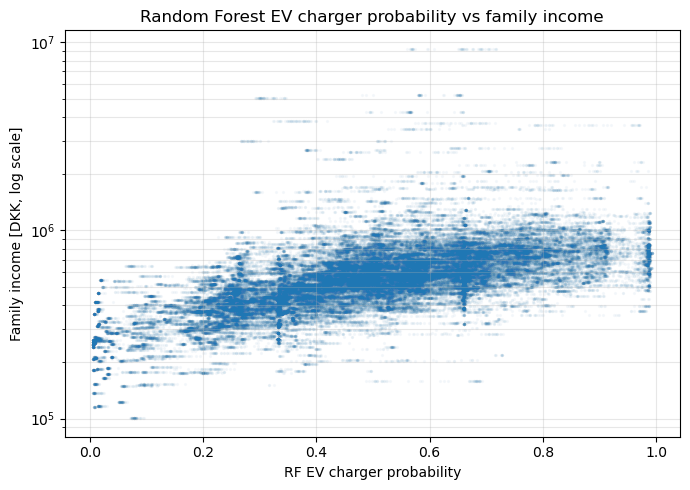

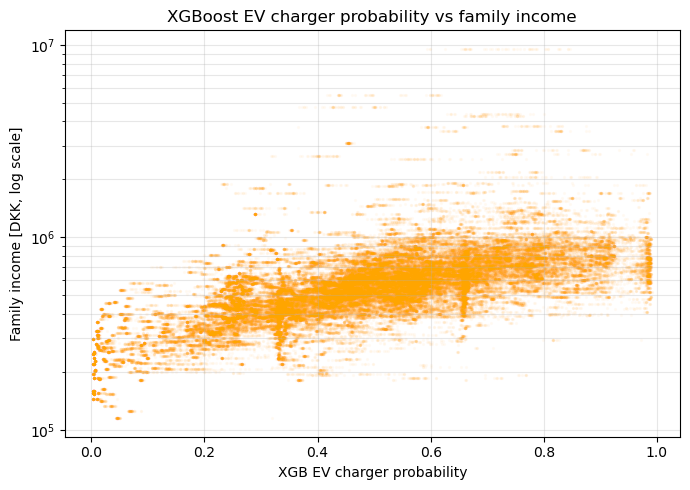

In [42]:
# Scatter plots
import matplotlib.pyplot as plt

# Convert only the needed columns to pandas/numpy for plotting
plot_df = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).to_pandas()

plot_df_log = plot_df[
    plot_df["Family_Income_rf"] > 0
].copy()

plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df_log["rf_EV_probability"],
    plot_df_log["Family_Income_rf"],
    alpha=0.03,
    s=2
)

plt.yscale("log")
plt.xlabel("RF EV charger probability")
plt.ylabel("Family income [DKK, log scale]")
plt.title("Random Forest EV charger probability vs family income")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

plot_df_log_xgb = plot_df[
    plot_df["Family_Income_xgb"] > 0
].copy()

plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df_log_xgb["xgb_EV_probability"],
    plot_df_log_xgb["Family_Income_xgb"],
    alpha=0.03,
    s=2,
    color="orange"
)

plt.yscale("log")
plt.xlabel("XGB EV charger probability")
plt.ylabel("Family income [DKK, log scale]")
plt.title("XGBoost EV charger probability vs family income")
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

##### Scatter plots for RF/XGB vs income correlation

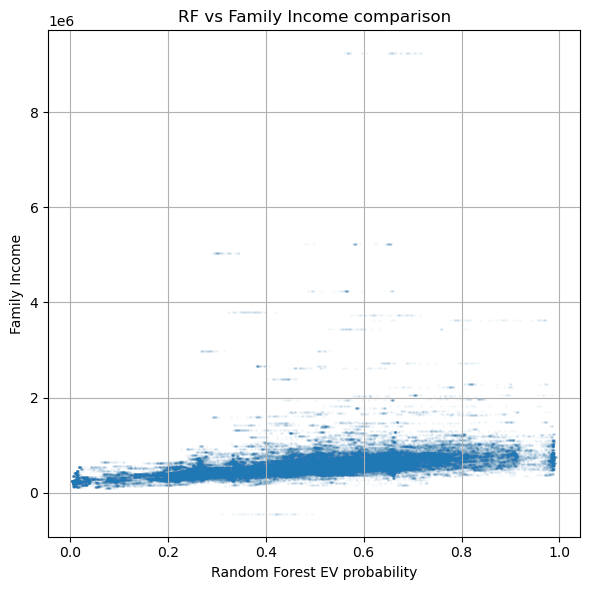

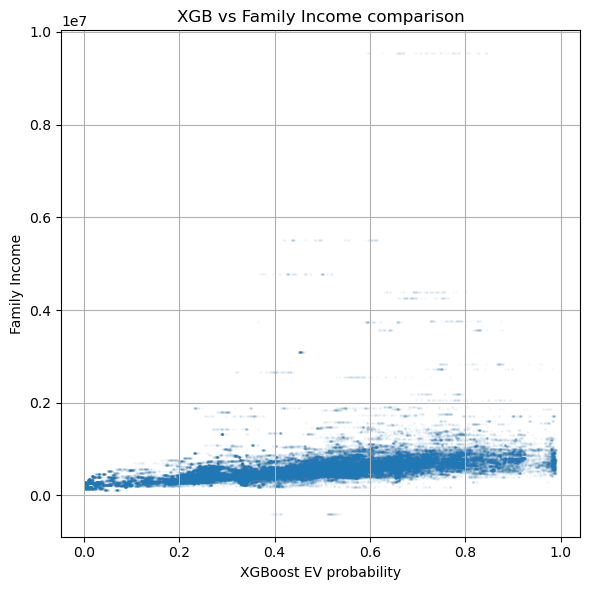

In [32]:
# Scatter plots
import matplotlib.pyplot as plt

# Convert only the needed columns to pandas/numpy for plotting
plot_df = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).to_pandas()

plt.figure(figsize=(6, 6))
plt.scatter(
    plot_df["rf_EV_probability"],
    plot_df["Family_Income_rf"],
    alpha=0.03,
    s=1
)

plt.xlabel("Random Forest EV probability")
plt.ylabel("Family Income")
plt.title("RF vs Family Income comparison")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    plot_df["xgb_EV_probability"],
    plot_df["Family_Income_xgb"],
    alpha=0.03,
    s=1
)

plt.xlabel("XGBoost EV probability")
plt.ylabel("Family Income")
plt.title("XGB vs Family Income comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


##### XGBoost EV charger probability vs income level bar chart

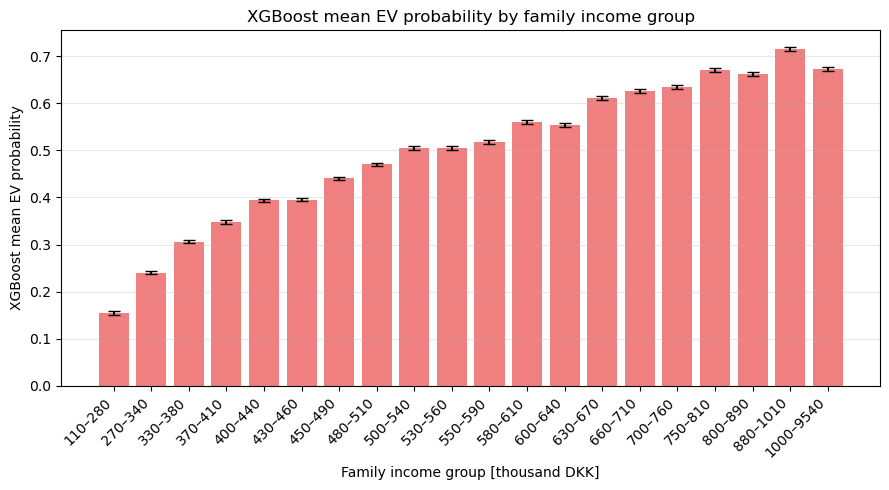

In [26]:
# binned income bar chart for XGBoost
import math

plot_bar = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).drop_nulls().to_pandas()

plot_bar = plot_bar[
    (plot_bar["Family_Income_rf"] >= 0) &
    (plot_bar["Family_Income_xgb"] >= 0)
].copy()

plot_bar["xgb_income_bin"] = pd.qcut(
    plot_bar["Family_Income_xgb"],
    q=20,
    duplicates="drop"
)
plot_bar = plot_bar[
    (plot_bar["Family_Income_rf"] >= 0) &
    (plot_bar["Family_Income_xgb"] >= 0)
].copy()

plot_bar["xgb_income_bin_label"] = plot_bar["xgb_income_bin"].apply(
    lambda x: f"{math.floor((x.left / 1000) / 10) * 10:.0f}–{math.ceil((x.right / 1000) / 10) * 10:.0f}"
)

xgb_binned = (
    plot_bar
    .groupby(["xgb_income_bin", "xgb_income_bin_label"], observed=True)
    .agg(
        mean_xgb_EV_probability=("xgb_EV_probability", "mean"),
        std_xgb_EV_probability=("xgb_EV_probability", "std"),
        n_obs=("xgb_EV_probability", "size")
    )
    .reset_index()
    .sort_values("xgb_income_bin")
)

xgb_binned["ci95"] = 1.96 * xgb_binned["std_xgb_EV_probability"] / np.sqrt(xgb_binned["n_obs"])

plt.figure(figsize=(9, 5))

plt.bar(
    xgb_binned["xgb_income_bin_label"],
    xgb_binned["mean_xgb_EV_probability"],
    yerr=xgb_binned["ci95"],
    capsize=4,
    color="lightcoral"
)

plt.xlabel("Family income group [thousand DKK]")
plt.ylabel("XGBoost mean EV probability")
plt.title("XGBoost mean EV probability by family income group")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

##### RF EV charger probability vs income level bar chart

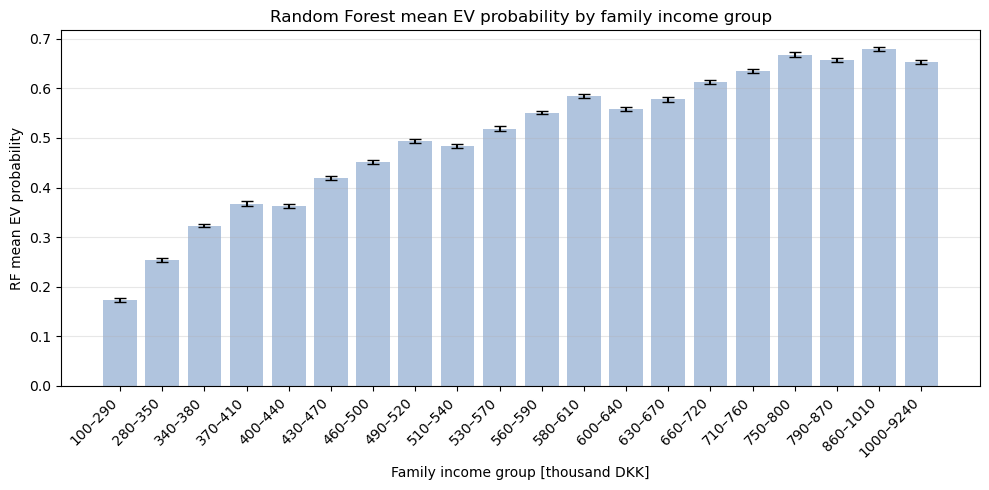

In [30]:
# Create income bins
import math

plot_bar = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).drop_nulls().to_pandas()

plot_bar = plot_bar[
    (plot_bar["Family_Income_rf"] >= 0) &
    (plot_bar["Family_Income_xgb"] >= 0)
].copy()

plot_bar["rf_income_bin"] = pd.qcut(
    plot_bar["Family_Income_rf"],
    q=20,
    duplicates="drop"
)

#Create cleaner labels in thousand DKK
plot_bar["rf_income_bin_label"] = plot_bar["rf_income_bin"].apply(
    lambda x: f"{math.floor((x.left / 1000) / 10) * 10:.0f}–{math.ceil((x.right / 1000) / 10) * 10:.0f}"
)
rf_binned = (
    plot_bar
    .groupby(["rf_income_bin", "rf_income_bin_label"], observed=True)
    .agg(
        mean_rf_EV_probability=("rf_EV_probability", "mean"),
        std_rf_EV_probability=("rf_EV_probability", "std"),
        n_obs=("rf_EV_probability", "size")
    )
    .reset_index()
    .sort_values("rf_income_bin")
)

rf_binned["ci95"] = (
    1.96 * rf_binned["std_rf_EV_probability"] / np.sqrt(rf_binned["n_obs"])
)
plt.figure(figsize=(10, 5))

plt.bar(
    rf_binned["rf_income_bin_label"],
    rf_binned["mean_rf_EV_probability"],
    yerr=rf_binned["ci95"],
    capsize=4,
    color="lightsteelblue"
)

plt.xlabel("Family income group [thousand DKK]")
plt.ylabel("RF mean EV probability")
plt.title("Random Forest mean EV probability by family income group")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

##### Combined EV charger probability vs income level bar chart


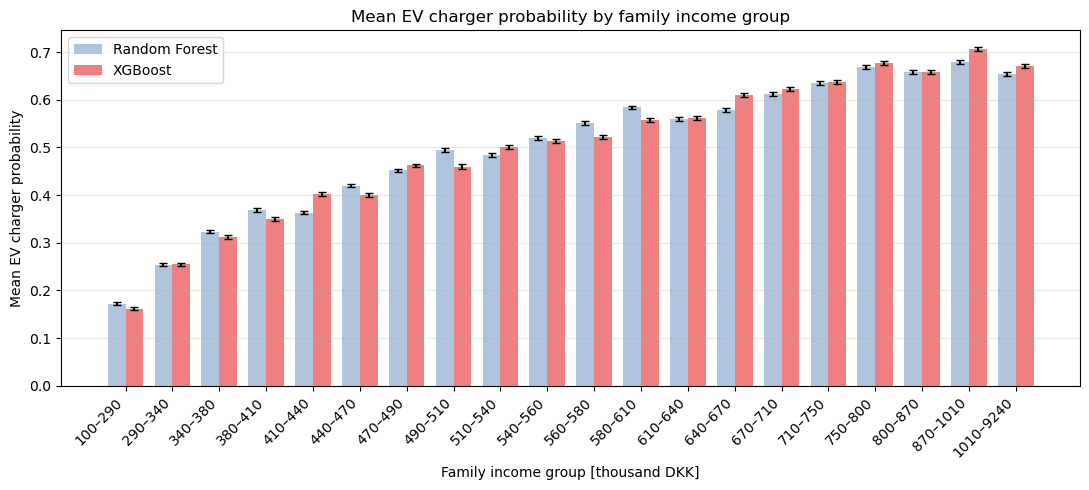

In [46]:
# combined bar chart with common bins and labels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

plot_bar = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).drop_nulls().to_pandas()

plot_bar = plot_bar[
    (plot_bar["Family_Income_rf"] >= 0) &
    (plot_bar["Family_Income_xgb"] >= 0)
].copy()

_, bin_edges = pd.qcut(
    plot_bar["Family_Income_rf"],
    q=20,
    duplicates="drop",
    retbins=True
)

# Widen edges slightly so XGB values also fit
# bin_edges[0] = min(bin_edges[0], plot_bar["Family_Income_xgb"].min()) - 1e-6
# bin_edges[-1] = max(bin_edges[-1], plot_bar["Family_Income_xgb"].max()) + 1e-6

# Clean labels in thousand DKK, rounded down/up to nearest 10
# labels = [
#     f"{math.floor((bin_edges[i] / 1000) / 10) * 10:.0f}–"
#     f"{math.ceil((bin_edges[i + 1] / 1000) / 10) * 10:.0f}"
#     for i in range(len(bin_edges) - 1)
# ]

# Convert bin edges to thousand DKK
edges_kDKK = bin_edges / 1000

# Round display edges to nearest 10 thousand DKK
display_edges = np.round(edges_kDKK / 10) * 10

# Make first edge rounded down and last edge rounded up
display_edges[0] = np.floor(edges_kDKK[0] / 10) * 10
display_edges[-1] = np.ceil(edges_kDKK[-1] / 10) * 10

# Ensure edges are strictly increasing after rounding
for i in range(1, len(display_edges)):
    if display_edges[i] <= display_edges[i - 1]:
        display_edges[i] = display_edges[i - 1] + 10

# Create clean contiguous labels
labels = [
    f"{display_edges[i]:.0f}–{display_edges[i + 1]:.0f}"
    for i in range(len(display_edges) - 1)
]

plot_bar["rf_income_bin"] = pd.cut(
    plot_bar["Family_Income_rf"],
    bins=bin_edges,
    labels=labels,
    include_lowest=True
)

plot_bar["xgb_income_bin"] = pd.cut(
    plot_bar["Family_Income_xgb"],
    bins=bin_edges,
    labels=labels,
    include_lowest=True
)

rf_binned = (
    plot_bar
    .groupby("rf_income_bin", observed=True)
    .agg(
        rf_mean=("rf_EV_probability", "mean"),
        rf_std=("rf_EV_probability", "std"),
        rf_n=("rf_EV_probability", "size")
    )
)

xgb_binned = (
    plot_bar
    .groupby("xgb_income_bin", observed=True)
    .agg(
        xgb_mean=("xgb_EV_probability", "mean"),
        xgb_std=("xgb_EV_probability", "std"),
        xgb_n=("xgb_EV_probability", "size")
    )
)

summary = pd.concat([rf_binned, xgb_binned], axis=1).reset_index()
summary = summary.rename(columns={"index": "income_bin"})

summary["rf_ci95"] = 1.96 * summary["rf_std"] / np.sqrt(summary["rf_n"])
summary["xgb_ci95"] = 1.96 * summary["xgb_std"] / np.sqrt(summary["xgb_n"])

summary
x = np.arange(len(summary))
width = 0.38

plt.figure(figsize=(11, 5))

plt.bar(
    x - width / 2,
    summary["rf_mean"],
    width,
    yerr=summary["rf_ci95"],
    capsize=3,
    label="Random Forest",
    color="lightsteelblue"
)

plt.bar(
    x + width / 2,
    summary["xgb_mean"],
    width,
    yerr=summary["xgb_ci95"],
    capsize=3,
    label="XGBoost",
    color="lightcoral"
)

plt.xticks(
    x,
    summary["income_bin"].astype(str),
    rotation=45,
    ha="right"
)

plt.xlabel("Family income group [thousand DKK]")
plt.ylabel("Mean EV charger probability")
plt.title("Mean EV charger probability by family income group")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

##### EV chargers probability line and band plot

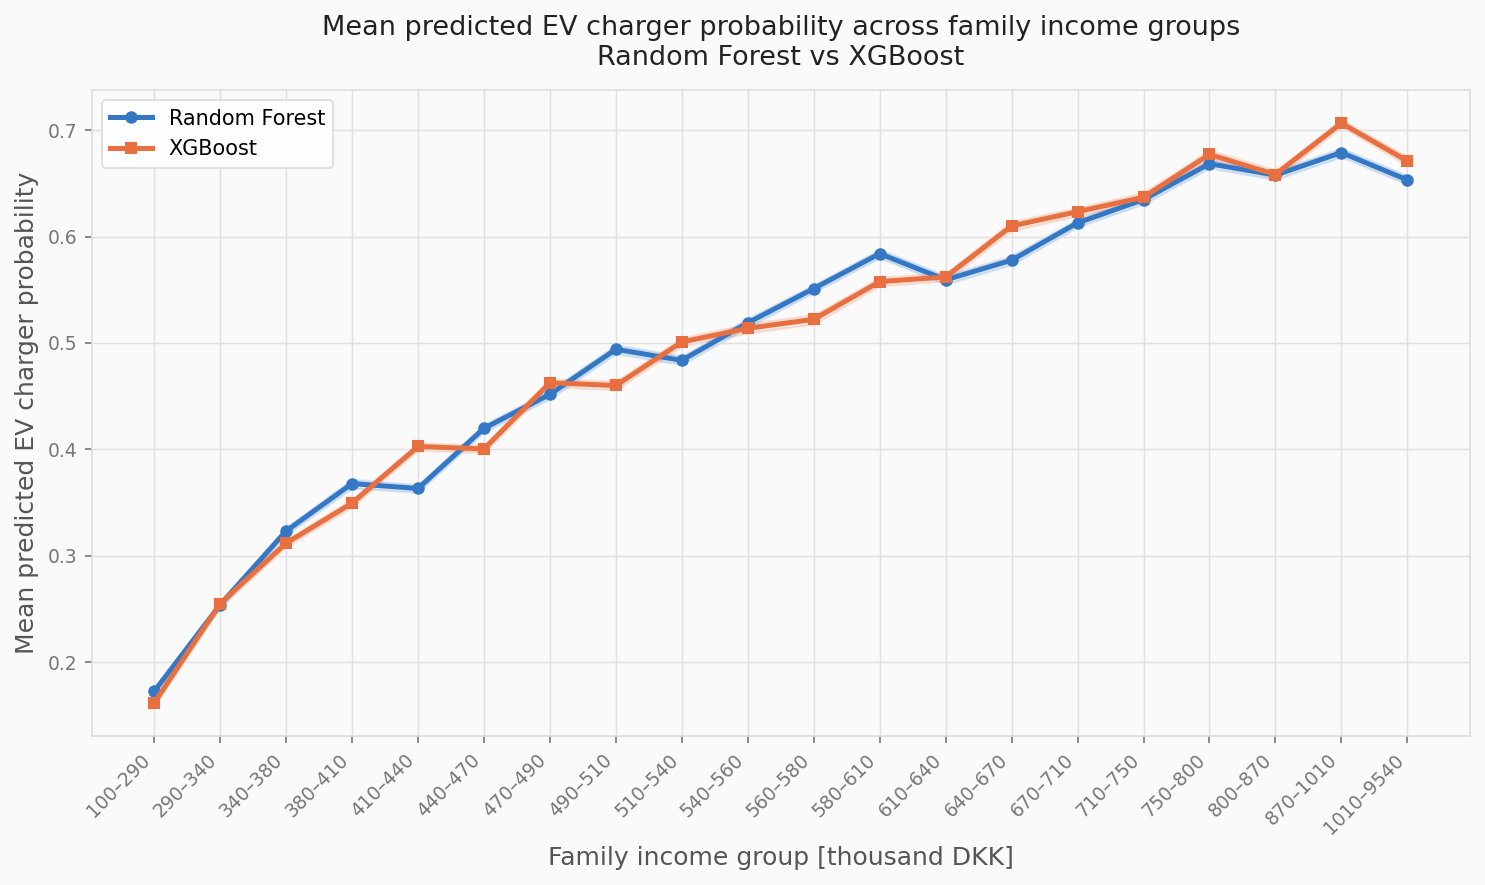

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ── Select and clean data ─────────────────────────────────────────────────────
plot_df = df_corr.select([
    "rf_EV_probability",
    "Family_Income_rf",
    "xgb_EV_probability",
    "Family_Income_xgb"
]).drop_nulls().to_pandas()

# Drop negative income values
plot_df = plot_df[
    (plot_df["Family_Income_rf"] >= 0) &
    (plot_df["Family_Income_xgb"] >= 0)
].copy()

# ── Create common income bins from RF income ──────────────────────────────────
q = 20

_, bin_edges = pd.qcut(
    plot_df["Family_Income_rf"],
    q=q,
    duplicates="drop",
    retbins=True
)

# Extend edges so XGB income values are also included
bin_edges[0] = min(bin_edges[0], plot_df["Family_Income_xgb"].min()) - 1e-6
bin_edges[-1] = max(bin_edges[-1], plot_df["Family_Income_xgb"].max()) + 1e-6

# Create clean contiguous labels in thousand DKK
edges_kDKK = bin_edges / 1000

display_edges = np.round(edges_kDKK / 10) * 10
display_edges[0] = np.floor(edges_kDKK[0] / 10) * 10
display_edges[-1] = np.ceil(edges_kDKK[-1] / 10) * 10

for i in range(1, len(display_edges)):
    if display_edges[i] <= display_edges[i - 1]:
        display_edges[i] = display_edges[i - 1] + 10

income_labels = [
    f"{display_edges[i]:.0f}–{display_edges[i + 1]:.0f}"
    for i in range(len(display_edges) - 1)
]

# Apply the same bins to both income columns
plot_df["rf_income_bin"] = pd.cut(
    plot_df["Family_Income_rf"],
    bins=bin_edges,
    labels=income_labels,
    include_lowest=True
)

plot_df["xgb_income_bin"] = pd.cut(
    plot_df["Family_Income_xgb"],
    bins=bin_edges,
    labels=income_labels,
    include_lowest=True
)






# ── Aggregate by income group ─────────────────────────────────────────────────
rf_summary = (
    plot_df
    .groupby("rf_income_bin", observed=True)
    .agg(
        mean_rf=("rf_EV_probability", "mean"),
        std_rf=("rf_EV_probability", "std"),
        n_rf=("rf_EV_probability", "size")
    )
)

xgb_summary = (
    plot_df
    .groupby("xgb_income_bin", observed=True)
    .agg(
        mean_xgb=("xgb_EV_probability", "mean"),
        std_xgb=("xgb_EV_probability", "std"),
        n_xgb=("xgb_EV_probability", "size")
    )
)

summary = pd.concat([rf_summary, xgb_summary], axis=1).reset_index()
summary = summary.rename(columns={"index": "income_group"})

# Optional: remove bins with few observations
min_obs = 100
summary = summary[
    (summary["n_rf"] >= min_obs) &
    (summary["n_xgb"] >= min_obs)
].copy()

income_labels_plot = summary["income_group"].astype(str).tolist()

means_rf = summary["mean_rf"].to_numpy()
means_xgb = summary["mean_xgb"].to_numpy()

std_rf = summary["std_rf"].to_numpy()
std_xgb = summary["std_xgb"].to_numpy()

ci_rf = 1.96 * summary["std_rf"].to_numpy() / np.sqrt(summary["n_rf"].to_numpy())
ci_xgb = 1.96 * summary["std_xgb"].to_numpy() / np.sqrt(summary["n_xgb"].to_numpy())

x = np.arange(len(summary))

# ── Plot ─────────────────────────────────────────────────────────────────────
C_RF  = "#3478C5"
C_XGB = "#E87040"

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.plot(
    x,
    means_rf,
    color=C_RF,
    linewidth=2.4,
    marker="o",
    markersize=5,
    label="Random Forest"
)

ax.plot(
    x,
    means_xgb,
    color=C_XGB,
    linewidth=2.4,
    marker="s",
    markersize=5,
    label="XGBoost"
)

# ax.fill_between(
#     x,
#     means_rf - std_rf,
#     means_rf + std_rf,
#     color=C_RF,
#     alpha=0.15
# )

# ax.fill_between(
#     x,
#     means_xgb - std_xgb,
#     means_xgb + std_xgb,
#     color=C_XGB,
#     alpha=0.15
# )
ax.fill_between(x, means_rf - ci_rf, means_rf + ci_rf, color=C_RF, alpha=0.15)
ax.fill_between(x, means_xgb - ci_xgb, means_xgb + ci_xgb, color=C_XGB, alpha=0.15)

ax.set_xticks(x)
ax.set_xticklabels(income_labels_plot, rotation=45, ha="right", fontsize=9, color="#555")

ax.set_xlabel("Family income group [thousand DKK]", fontsize=12, color="#555")
ax.set_ylabel("Mean predicted EV charger probability", fontsize=12, color="#555")

ax.set_title(
    "Mean predicted EV charger probability across family income groups\nRandom Forest vs XGBoost",
    fontsize=13,
    color="#222",
    pad=12
)

ax.tick_params(colors="#777", labelsize=9)
ax.grid(color="#E0E0E0", linewidth=0.7)

for spine in ax.spines.values():
    spine.set_edgecolor("#DDDDDD")

ax.legend(fontsize=10, framealpha=0.9, edgecolor="#DDDDDD")

plt.tight_layout()
plt.savefig("ev_prob_income_line_band_rf_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
